## Task 1

In [14]:
from task_1 import generate_dataset
import numpy as np

random_generator = np.random.default_rng(42)
inputs_raw, outputs = generate_dataset(random_generator, dataset_size=500)

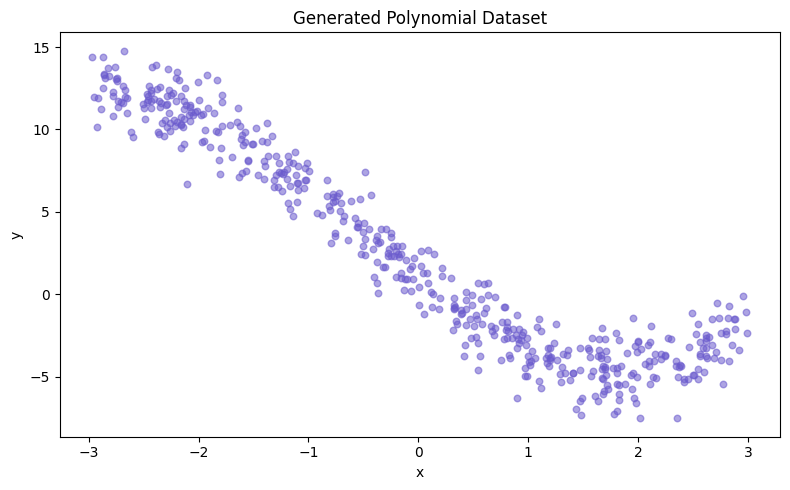

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(inputs_raw, outputs, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from shared import add_bias_term_to_inputs

degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
scaler = StandardScaler()
inputs_with_polynomial_features = scaler.fit_transform(
    poly.fit_transform(inputs_raw)
)
inputs = add_bias_term_to_inputs(inputs_with_polynomial_features)

In [21]:
from shared import (
    train_weights,
    add_bias_term_to_inputs,
    create_batch_gradient_descent_compute_new_weights_function,
)
epochs = 400
results_simple = []

batch_result = train_weights(
    inputs,
    initial_weights=np.zeros((inputs.shape[1], 1)),
    outputs=outputs,
    epochs=epochs,
    compute_new_weights_function=create_batch_gradient_descent_compute_new_weights_function(
        learning_rate=0.1
    )
)
batch_result.loss_history[-2]

1.4971529975942566

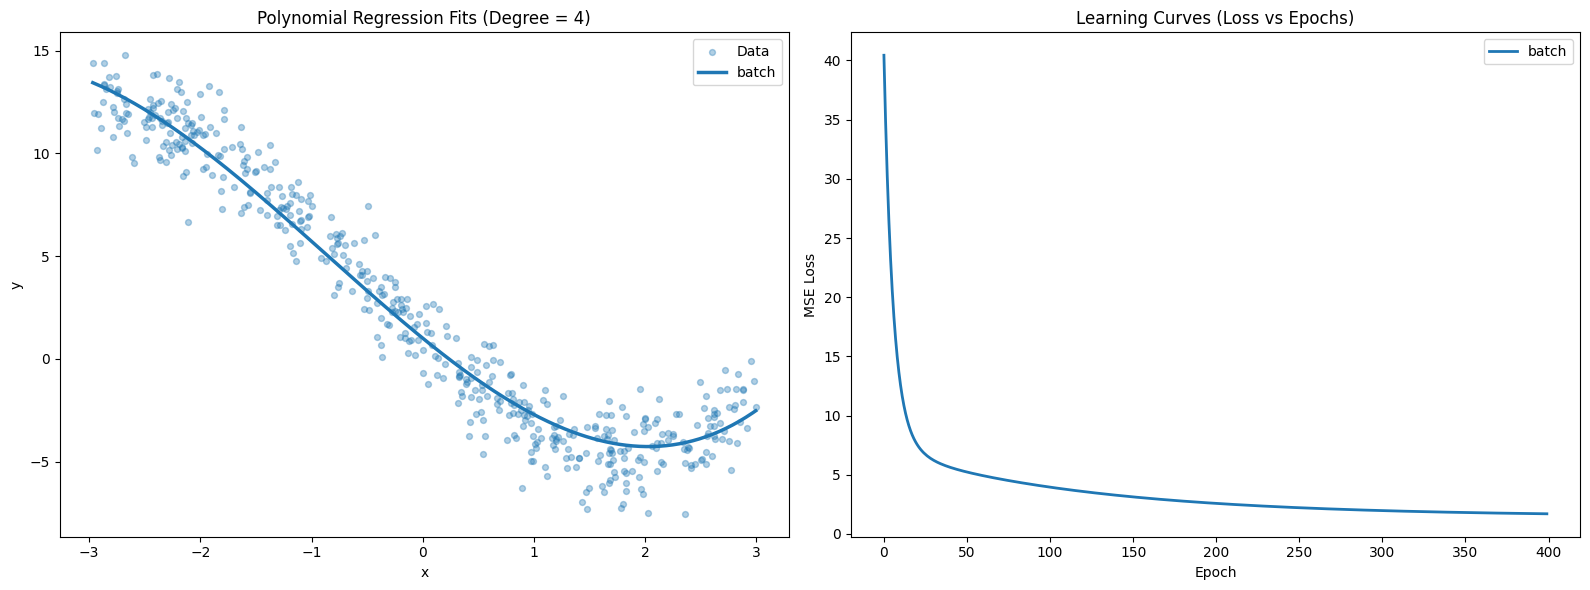

In [19]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(inputs_raw.min(), inputs_raw.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(inputs_raw, outputs, alpha=0.35, s=18, label="Data")
axes[0].plot(x_grid, X_grid_design @ batch_result.weights, linewidth=2.5, label="batch")

axes[0].set_title("Polynomial Regression Fits (Degree = 4)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(batch_result.loss_history, linewidth=2, label="batch")

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()